# Approximate Bayesian Computation

We compare the results with two algorithms in ABC, i.e. we compare the basic formulation of ABC with Importance Sampling ABC.

Let $x = (x_1, \cdots, x_{100})$ be an i.i.d from the following mixture model:

$$
\lambda \cdot Bin(x_i | \theta_1, N = 4) + (1 - \lambda) \cdot Bin(x_i| \theta_2, N=4)
$$

The parameters of interest are $\lambda$, $\theta_1$ and $\theta_2$. We want to get samples from
the posterior distribution

$$
p(\lambda, \theta_1, \theta_2 | x_1, \cdots, x_{100})
$$

by assuming the following prior distributions:

- $\lambda \sim U(0,1)$
- $(\theta_1, \theta_2)$ uniformly distributed over the set $\{(\theta_1, \theta_2): 0 \le \theta_2 \le \theta_1 \le 1\}$


## Initial Representation of the mixture

For this example we will use:

- $\theta_1 = 0.7$
- $\theta_2 = 0.2$
- $\lambda = 0.8$

Sampling from the real mixture $100$ observations we get the following histogram:


tensor(2.3500)


<Axes: ylabel='Count'>

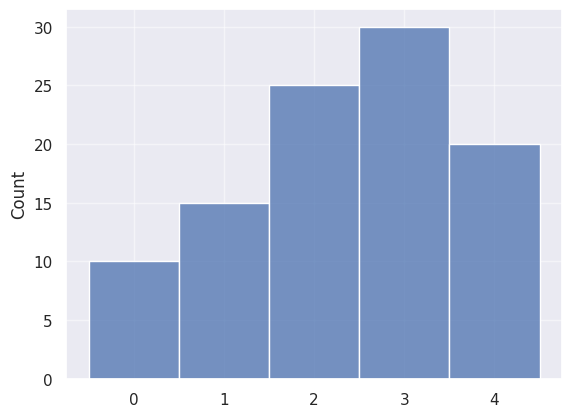

In [1]:
import matplotlib.pyplot as plt
import torch
from sympy.stats import density

from simulator import GenerativeProcess, BinomialMixtureSimulator
import seaborn as sns

sns.set_theme(style="darkgrid")

torch.manual_seed(1)
real_theta1 = 0.7
real_theta2 = 0.2
real_rate=0.8
x_obs = GenerativeProcess(real_theta1, real_theta2, real_rate).mixture.sample((100,))
s_obs = x_obs.mean()
print(s_obs)
sns.histplot(x_obs, discrete=True)

## Basic ABC Algorithm

In the basic formulation of ABC:

1. Propose parameters
2. Use a simulator to generate samples with the proposed parameters
3. Compute a statistic and a distance between statistics of observed data and simulated data
4. If the distance is smaller than a threshold, accept the proposed parameters

In [2]:
from sampler.base_abc import BaseABC

simulator = BinomialMixtureSimulator()

algo = BaseABC(
    observations=x_obs,
    simulator=simulator,
    summary_statistic="frequency",
    threshold=0.05,
)

n_sim = 50000
accepted = algo.compute(n_sim)
print(f"Acceptance ratio: {len(accepted) / n_sim * 100:.2f}%")

Acceptance ratio: 0.57%


The basic algorithm is computationally intensive, and it rejects lots of proposals that do not match the similarity condition.
After having at least one triplet of parameters accepted, we can use them to simulate as many data as we want from the simulator.

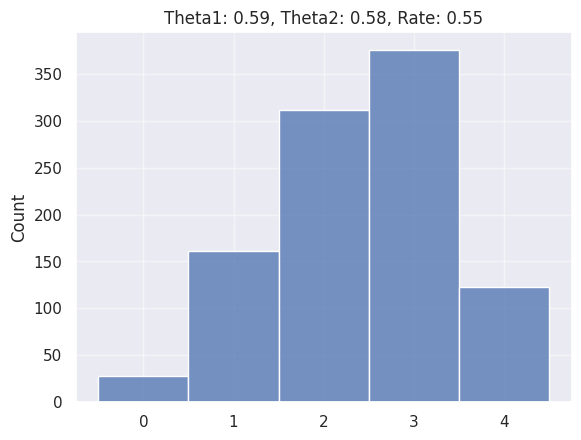

In [3]:
new_samples = simulator.generate(*accepted[0], times=1000)
sns.histplot(new_samples, discrete=True)
a_params = accepted[0]
plt.title(
    f"Theta1: {a_params[0]:.2f}, Theta2: {a_params[1]:.2f}, Rate: {a_params[2]:.2f}"
)
plt.show()

## Importance Sampling ABC

Instead of rejecting proposed parameters we can give a weight to all of them and calculate a weighted average to get the expectation of that parameter.

To do so we need to choose some proposals (apart from the priors) for the parameters of interests.
In our case we choose 2 Beta distributions.

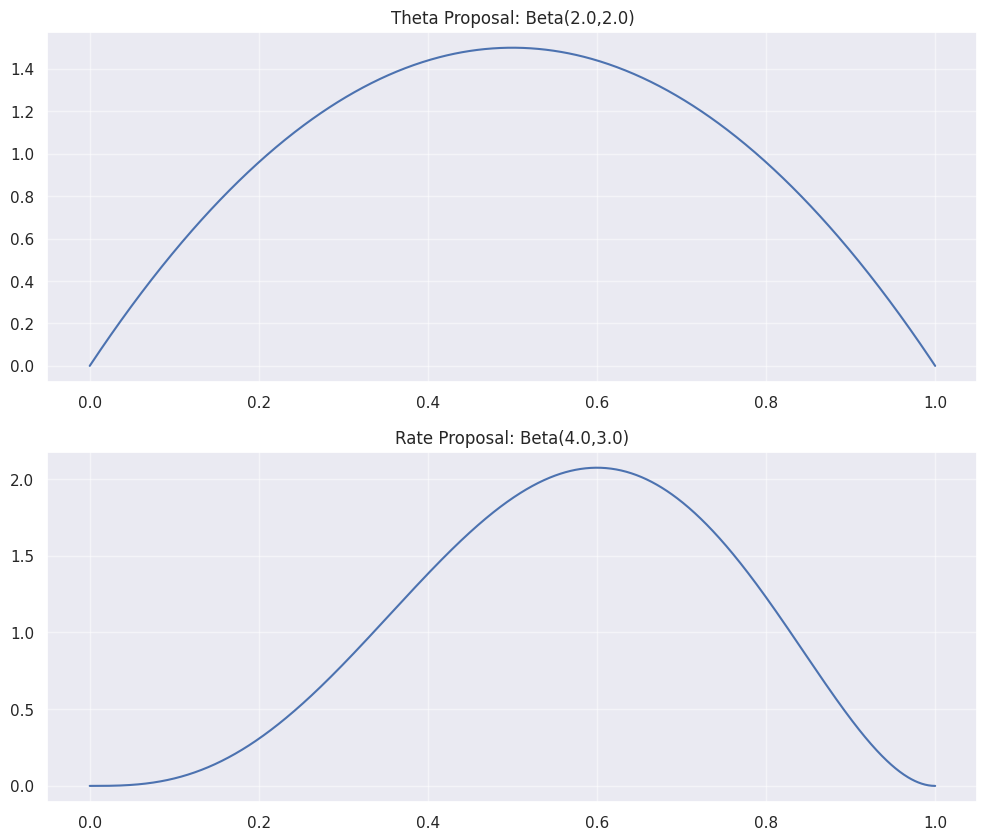

In [4]:
from importance_sampling import ImportanceSampling

imp_s = ImportanceSampling(
    observations=x_obs,
    simulator=simulator,
    summary_statistic="frequency",
    threshold=0.1,
)

imp_s.plot_proposals()

The fraction between the density of the prior and the density of the proposal gives the unnormalized weight of a specific parameter.

Given a prior $p$ and a proposal $g$ for a parameter $\theta$, to get the unnormalized weight $\tilde{w}_i$ of a specific $\theta_i \sim p$, we calculate the following ratio:
$$
\frac{p(\theta_i)}{g(\theta_i)}
$$

To get the normalized weight $w_i$ we simply calculate all the $N$ unnormalized weights and the total sum is the normalizing constant

$$
w_i = \frac{\tilde{w}_i}{\sum^N_{i=1 } w_i}
$$

The parameters that would be discarded in the previous algorithm are now weighted and used to calculate the expectation.

Using Importance Sampling will lead to the following parameters:


In [5]:
t1_is, t2_is, r_is, w_is = imp_s.compute(n_samples=5000)

t1 = (t1_is * w_is).sum()
t2 = (t2_is * w_is).sum()
r = (r_is * w_is).sum()

print(f"Expected Theta_1: {t1}\nExpected Theta_2: {t2}\nExpected Rate: {r}\n")

ess = 1 / torch.sum(w_is ** 2)
print(ess)

Expected Theta_1: 0.7098695039749146
Expected Theta_2: 0.3545520305633545
Expected Rate: 0.6153596639633179

tensor(746.8215)


Like in the basic algorithm we can use the parameters to sample from the simulator.

In [6]:
t1_a = []
r_a = []
for t1, t2, r in accepted:
    t1_a.append(t1)
    r_a.append(r)

t1_a = torch.tensor(t1_a)
# t1_a = t1_a / t1_a.sum()
r_a = torch.tensor(r_a)
# r_a = r_a / r_a.sum()


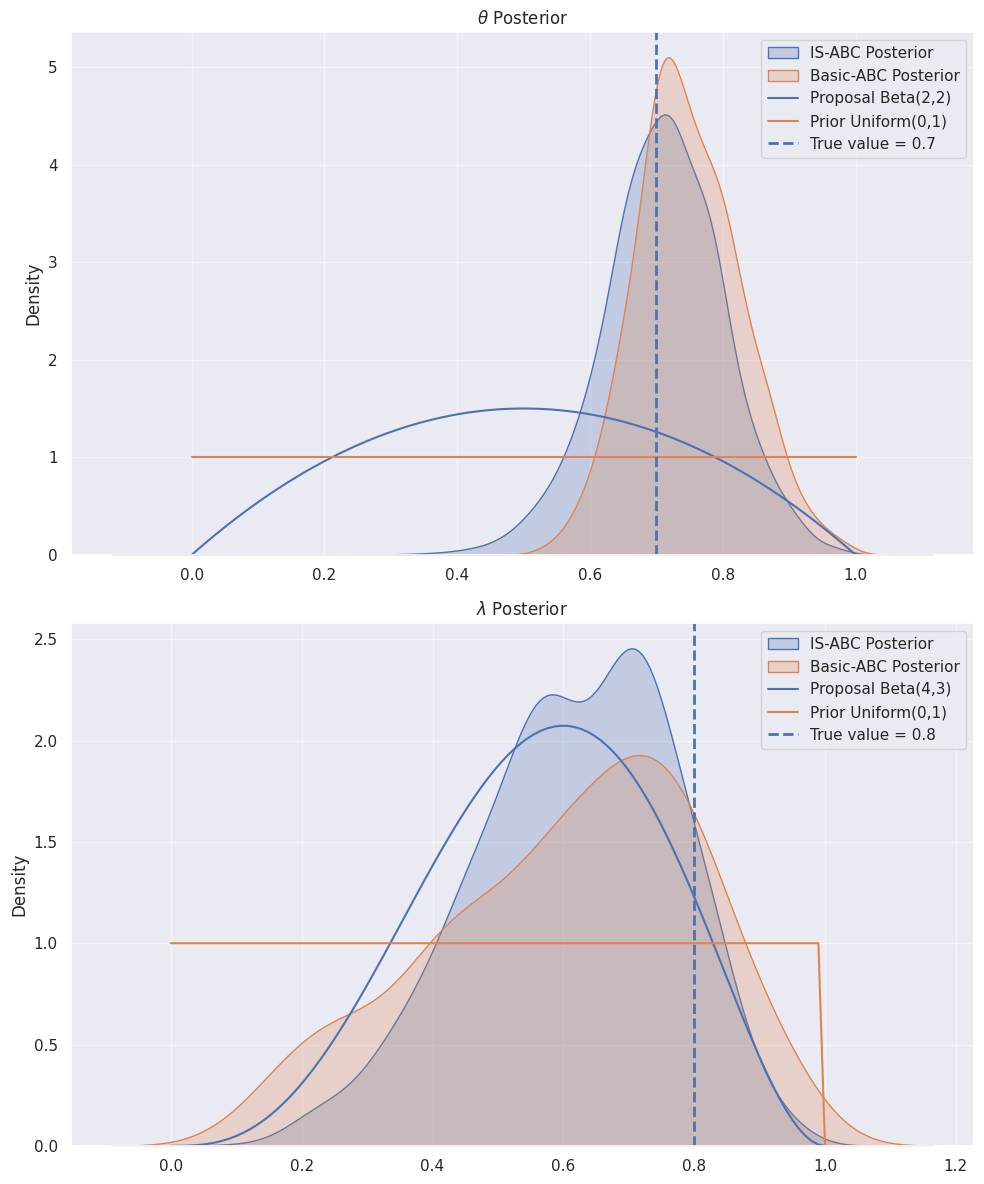

In [7]:
fig, ax = plt.subplots(2, figsize=(10, 12))

# ===== Theta1 posterior =====
sns.kdeplot(
    x=t1_is.numpy(),
    weights=w_is.numpy(),
    fill=True,
    ax=ax[0],
    label="IS-ABC Posterior"
)

sns.kdeplot(
    x=t1_a.numpy(),
    fill=True,
    ax=ax[0],
    label="Basic-ABC Posterior"
)

x = torch.linspace(0, 1, 100)

theta_proposal = torch.exp(
    imp_s.theta_proposal.log_prob(x)
)

ax[0].plot(
    x.numpy(),
    theta_proposal.numpy(),
    label="Proposal Beta(2,2)"
)

theta_prior = torch.exp(
    torch.distributions.Uniform(0,1).log_prob(x)
)

x_prior = torch.linspace(0, 1, 100)
prior = torch.ones_like(x_prior)

ax[0].plot(
    x_prior.numpy(),
    prior.numpy(),
    label="Prior Uniform(0,1)",
)

# true value
ax[0].axvline(
    real_theta1,
    linestyle="--",
    linewidth=2,
    label=f"True value = {real_theta1}"
)

ax[0].set_title(f"$\\theta$ Posterior")
ax[0].legend()


# ===== Rate posterior =====
sns.kdeplot(
    x=r_is.numpy(),
    weights=w_is.numpy(),
    fill=True,
    ax=ax[1],
    label="IS-ABC Posterior",
)

sns.kdeplot(
    x=r_a.numpy(),
    fill=True,
    ax=ax[1],
    label="Basic-ABC Posterior"
)

rate = torch.exp(
    imp_s.rate_proposal.log_prob(x)
)

ax[1].plot(
    x.numpy(),
    rate.numpy(),
    label="Proposal Beta(4,3)"
)

ax[1].plot(
    x.numpy(),
    theta_prior.numpy(),
    label="Prior Uniform(0,1)"
)

# true value
ax[1].axvline(
    real_rate,
    linestyle="--",
    linewidth=2,
    label=f"True value = {real_rate}"
)

ax[1].set_title(f"$\\lambda$ Posterior")
ax[1].legend()

plt.tight_layout()
plt.show()

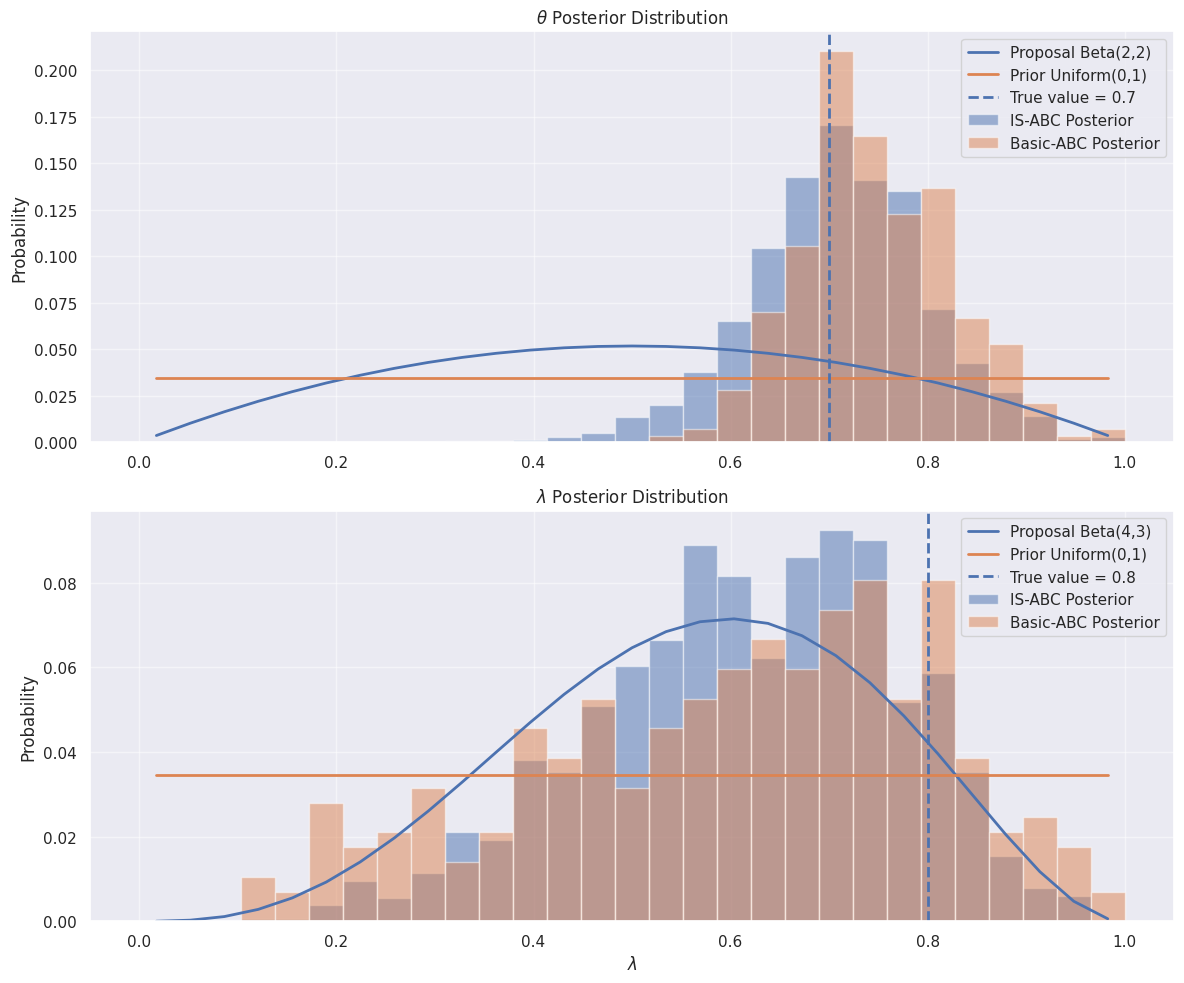

In [9]:
import numpy as np
import matplotlib.pyplot as plt

fig, ax = plt.subplots(2, figsize=(12, 10))

# =========================================================
# Common bins
# =========================================================

bins = np.linspace(0, 1, 30)
bin_centers = 0.5 * (bins[:-1] + bins[1:])
width = np.diff(bins)
basic_theta = t1_a
basic_rate = r_a
# =========================================================
# THETA
# =========================================================

# IS-ABC posterior
hist_is_theta, _ = np.histogram(
    t1_is.numpy(),
    bins=bins,
    weights=w_is.numpy()
)
hist_is_theta = hist_is_theta / hist_is_theta.sum()

# Basic ABC posterior
hist_basic_theta, _ = np.histogram(
    basic_theta.numpy(),
    bins=bins
)
hist_basic_theta = hist_basic_theta / hist_basic_theta.sum()

# Proposal
proposal_theta = torch.exp(
    imp_s.theta_proposal.log_prob(torch.tensor(bin_centers))
).numpy()

proposal_theta = proposal_theta / proposal_theta.sum()

# Prior Uniform(0,1)
prior_theta = np.ones_like(bin_centers)
prior_theta = prior_theta / prior_theta.sum()

# plots
ax[0].bar(
    bin_centers,
    hist_is_theta,
    width=width,
    alpha=0.5,
    label="IS-ABC Posterior"
)

ax[0].bar(
    bin_centers,
    hist_basic_theta,
    width=width,
    alpha=0.5,
    label="Basic-ABC Posterior"
)

ax[0].plot(
    bin_centers,
    proposal_theta,
    linewidth=2,
    label="Proposal Beta(2,2)"
)

ax[0].plot(
    bin_centers,
    prior_theta,
    linewidth=2,
    label="Prior Uniform(0,1)"
)

ax[0].axvline(
    0.7,
    linestyle="--",
    linewidth=2,
    label="True value = 0.7"
)

ax[0].set_title(r"$\theta$ Posterior Distribution")
ax[0].set_ylabel("Probability")
ax[0].legend()


# =========================================================
# RATE / LAMBDA
# =========================================================

hist_is_rate, _ = np.histogram(
    r_is.numpy(),
    bins=bins,
    weights=w_is.numpy()
)
hist_is_rate = hist_is_rate / hist_is_rate.sum()

hist_basic_rate, _ = np.histogram(
    basic_rate.numpy(),
    bins=bins
)
hist_basic_rate = hist_basic_rate / hist_basic_rate.sum()

proposal_rate = torch.exp(
    imp_s.rate_proposal.log_prob(torch.tensor(bin_centers))
).numpy()

proposal_rate = proposal_rate / proposal_rate.sum()

prior_rate = np.ones_like(bin_centers)
prior_rate = prior_rate / prior_rate.sum()

ax[1].bar(
    bin_centers,
    hist_is_rate,
    width=width,
    alpha=0.5,
    label="IS-ABC Posterior",
)

ax[1].bar(
    bin_centers,
    hist_basic_rate,
    width=width,
    alpha=0.5,
    label="Basic-ABC Posterior"
)

ax[1].plot(
    bin_centers,
    proposal_rate,
    linewidth=2,
    label="Proposal Beta(4,3)"
)

ax[1].plot(
    bin_centers,
    prior_rate,
    linewidth=2,
    label="Prior Uniform(0,1)"
)

ax[1].axvline(
    0.8,
    linestyle="--",
    linewidth=2,
    label="True value = 0.8"
)

ax[1].set_title(r"$\lambda$ Posterior Distribution")
ax[1].set_xlabel(r"$\lambda$")
ax[1].set_ylabel("Probability")
ax[1].legend()

plt.tight_layout()
plt.show()